<a href="https://colab.research.google.com/github/prvallejoz/ejercicio3-mcib-b/blob/dev_bryan/TAREA_3_GRUPO_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:

# 1. IMPORTACIÓN DE LIBRERÍAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

sns.set(style="whitegrid")


In [76]:
# 2. CARGA DEL DATASET

# Cargar los datos desde la ruta indicada
data = pd.read_csv('/content/hotel_bookings.csv')

# Mostrar dimensiones y primeras 5 filas
print("Dimensiones del dataset:", data.shape)
data.head()

Dimensiones del dataset: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [77]:
# 3. LIMPIEZA DE DATOS

# Eliminar registros duplicados

print("Dimensiones iniciales:", data.shape)
print("\nTipos de datos:")
print(data.dtypes)

Dimensiones iniciales: (119390, 32)

Tipos de datos:
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type           

In [78]:
print("\nPrimeras filas:")
display(data.head())


Primeras filas:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [79]:
print("\nValores nulos por columna:")
display(data.isnull().sum().sort_values(ascending=False))


Valores nulos por columna:


,0
company,112593
agent,16340
country,488
children,4
arrival_date_month,0
arrival_date_week_number,0
hotel,0
is_canceled,0
stays_in_weekend_nights,0
arrival_date_day_of_month,0


In [80]:
print("\nDuplicados exactos detectados:", data.duplicated().sum())


Duplicados exactos detectados: 31994


In [81]:
duplicados_antes = data.duplicated().sum()

data.drop_duplicates(inplace=True)

duplicados_despues = data.duplicated().sum()

print("Duplicados antes:", duplicados_antes)
print("Duplicados después:", duplicados_despues)
print("Nuevo shape:", data.shape)

Duplicados antes: 31994
Duplicados después: 0
Nuevo shape: (87396, 32)


In [82]:
# 4. ANALISÍS DE COLUMNAS

# % de nulos
null_pct = (data.isnull().sum() / len(data) * 100).sort_values(ascending=False)

diagnostico = pd.DataFrame({
    'tipo_dato': data.dtypes,
    'nulos': data.isnull().sum(),
    '%_nulos': round((data.isnull().sum()/len(data))*100,2),
    'valores_unicos': data.nunique()
})

display(diagnostico.sort_values('%_nulos', ascending=False))

,tipo_dato,nulos,%_nulos,valores_unicos
company,float64,82137,93.98,352
agent,float64,12193,13.95,333
country,object,452,0.52,177
hotel,object,0,0.00,2
arrival_date_month,object,0,0.00,12
arrival_date_week_number,int64,0,0.00,53
lead_time,int64,0,0.00,479
is_canceled,int64,0,0.00,2
stays_in_weekend_nights,int64,0,0.00,17
stays_in_week_nights,int64,0,0.00,35


In [83]:
#5. ELIMINAR COLUMNAS DE DATASET

columnas_a_borrar = ['company', 'agent', 'reservation_status', 'reservation_status_date']

data.drop(columns=columnas_a_borrar, inplace=True, errors='ignore')

print("Columnas eliminadas correctamente.")
print("Nuevo total columnas:", data.shape[1])

Columnas eliminadas correctamente.
Nuevo total columnas: 28


In [84]:
# 6 ANALIZAR NULOS DE COLUMNAS CHILDREN Y COUNTRY

cols_null = ['children', 'country']

for col in cols_null:
    if col in data.columns:
        print(f"{col} -> nulos antes:", data[col].isnull().sum())

children -> nulos antes: 4
country -> nulos antes: 452


In [85]:
# Rellenar valores faltantes
data['children'] = data['children'].fillna(data['children'].mode()[0])
data['country'] = data['country'].fillna(data['country'].mode()[0])

In [86]:
# 7. VALIDACIÓN GENERAL DE VALORES NULOS

nulos = data.isnull().sum()
nulos_restantes = nulos[nulos > 0]

print("Columnas con nulos restantes:")
display(nulos_restantes.sort_values(ascending=False))

print("Total nulos restantes:", nulos_restantes.sum())

Columnas con nulos restantes:


,0


Total nulos restantes: 0


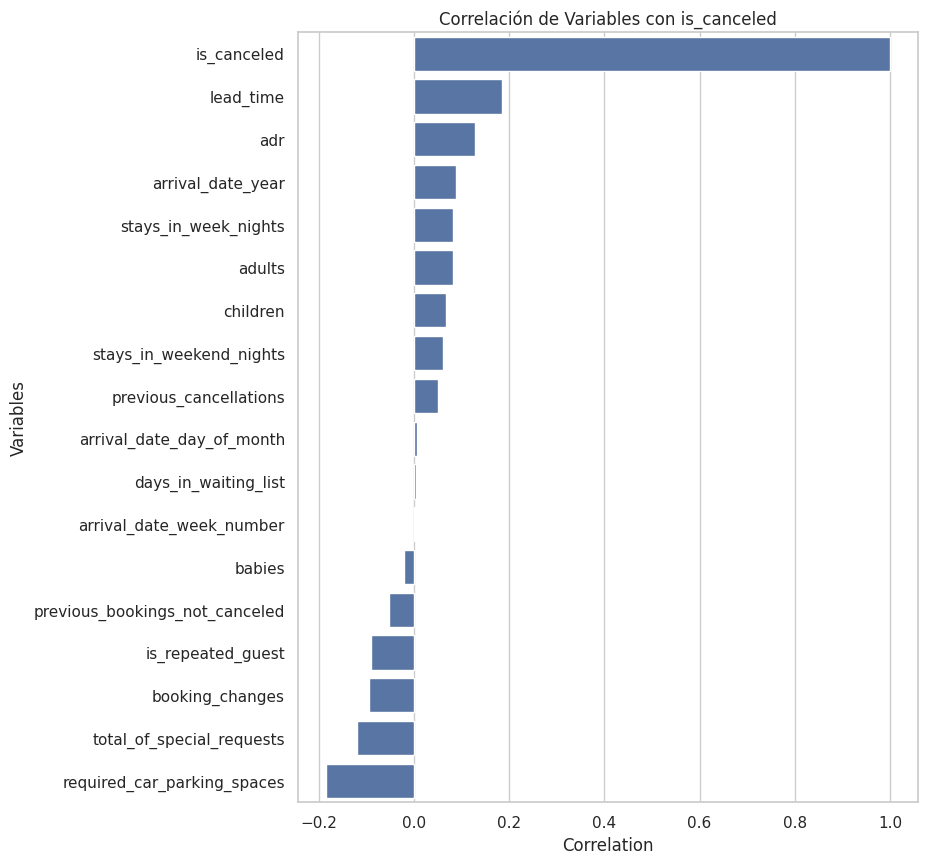

is_canceled                       1.000000
lead_time                         0.184806
adr                               0.127986
arrival_date_year                 0.088030
stays_in_week_nights              0.082928
adults                            0.081816
children                          0.067369
stays_in_weekend_nights           0.060191
previous_cancellations            0.051468
arrival_date_day_of_month         0.005328
days_in_waiting_list              0.004464
arrival_date_week_number          0.001443
babies                           -0.020543
previous_bookings_not_canceled   -0.052154
is_repeated_guest                -0.089643
booking_changes                  -0.093644
total_of_special_requests        -0.120545
required_car_parking_spaces      -0.184206
Name: is_canceled, dtype: float64


In [87]:

# 8. CORRELACIÓN CON LA VARIABLE TARGET
# Identificar variables mas relacionada con la cancelacion

corr_target = data.select_dtypes(include=np.number).corr()['is_canceled'].sort_values(ascending=False)

plt.figure(figsize=(8,10))
sns.barplot(x=corr_target.values, y=corr_target.index)
plt.title("Correlación de Variables con is_canceled")
plt.xlabel("Correlation")
plt.ylabel("Variables")
plt.show()

print(corr_target)

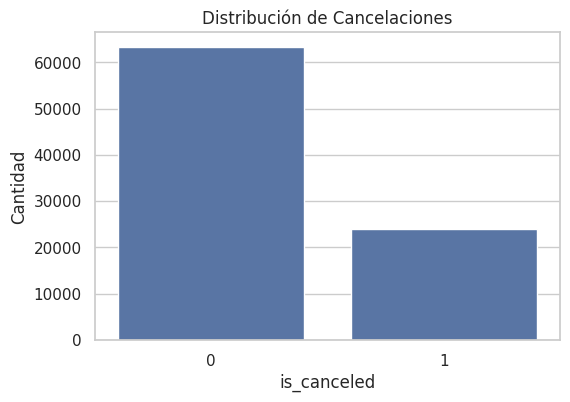

is_canceled
0    0.725102
1    0.274898
Name: proportion, dtype: float64


In [88]:
# 9. DISTRIBUCIÓN DE LA VARIABLE TARGET
# Revisar balance de clases
plt.figure(figsize=(6,4))
sns.countplot(x='is_canceled', data=data)
plt.title("Distribución de Cancelaciones")
plt.xlabel("is_canceled")
plt.ylabel("Cantidad")
plt.show()

print(data['is_canceled'].value_counts(normalize=True))

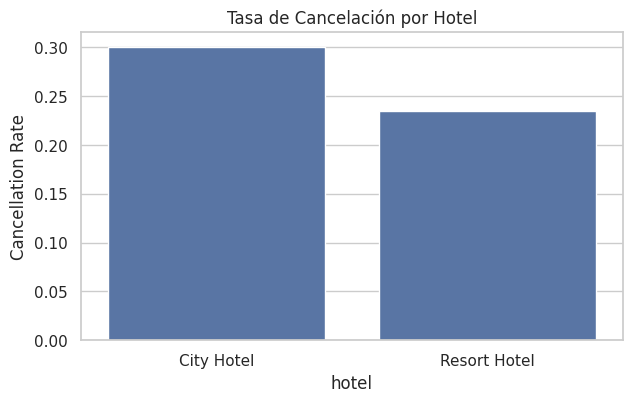

In [89]:
# 10. CANCELACIÓN POR TIPO DE HOTEL

cancel_hotel = data.groupby('hotel')['is_canceled'].mean().sort_values(ascending=False)

plt.figure(figsize=(7,4))
sns.barplot(x=cancel_hotel.index, y=cancel_hotel.values)
plt.title("Tasa de Cancelación por Hotel")
plt.ylabel("Cancellation Rate")
plt.show()

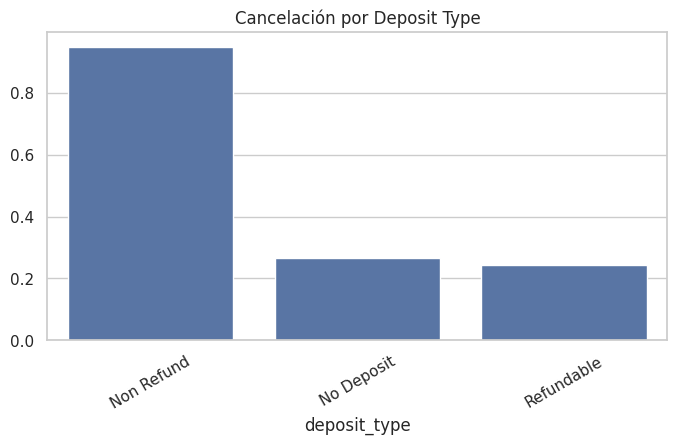

In [90]:
# 11. CANCELACIÓN POR TIPO DE DEPÓSITO

cancel_dep = data.groupby('deposit_type')['is_canceled'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x=cancel_dep.index, y=cancel_dep.values)
plt.title("Cancelación por Deposit Type")
plt.xticks(rotation=30)
plt.show()

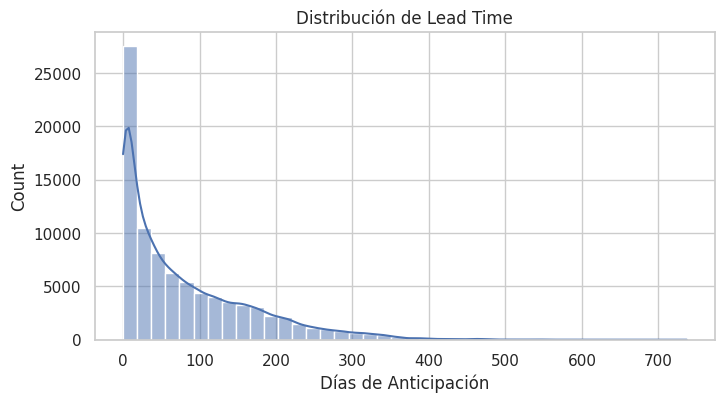

In [91]:
# 12. DISTRIBUCIÓN DE lead_time
# Ver comportamiento reservas anticipadas
plt.figure(figsize=(8,4))
sns.histplot(data['lead_time'], bins=40, kde=True)
plt.title("Distribución de Lead Time")
plt.xlabel("Días de Anticipación")
plt.show()

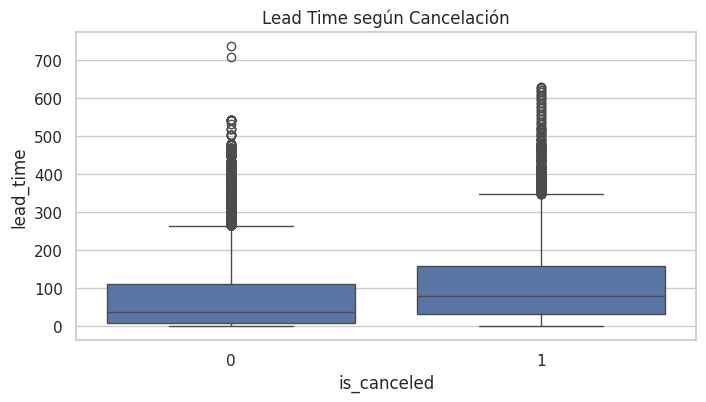

In [92]:
# 13. lead_time vs cancelación

plt.figure(figsize=(8,4))
sns.boxplot(x='is_canceled', y='lead_time', data=data)
plt.title("Lead Time según Cancelación")
plt.show()

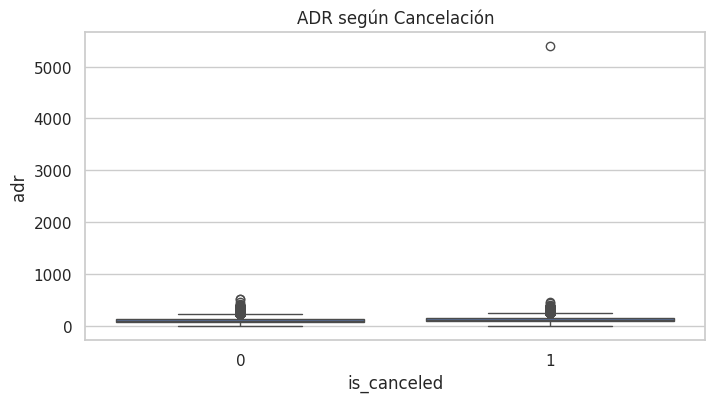

In [93]:
# 14. ADR vs cancelación
# Revisar si precio influye

plt.figure(figsize=(8,4))
sns.boxplot(x='is_canceled', y='adr', data=data)
plt.title("ADR según Cancelación")
plt.show()

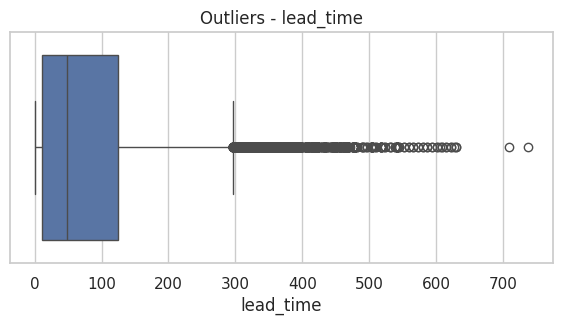

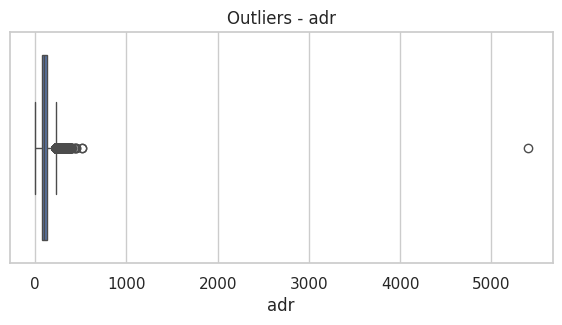

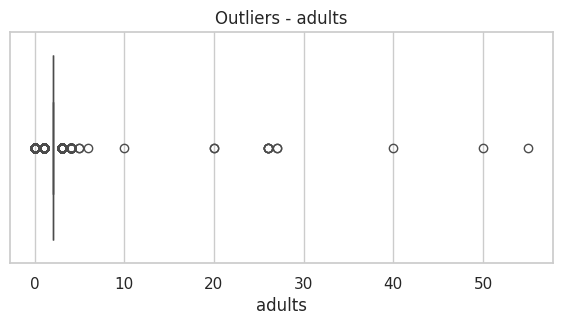

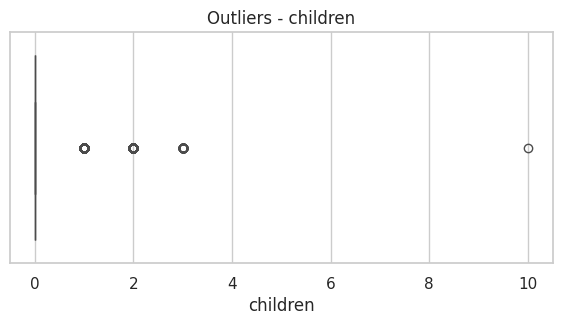

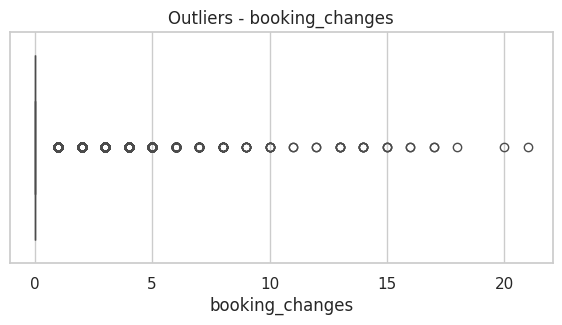

In [94]:
# 15. OUTLIERS NUMÉRICOS
# Detectar valores extremos

num_cols = ['lead_time','adr','adults','children','booking_changes']

for col in num_cols:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=data[col])
    plt.title(f"Outliers - {col}")
    plt.show()

In [95]:
# 16. FEATURE ENGINEERING
# Crear nuevas variables útiles

data['total_guests'] = data['adults'] + data['children'] + data['babies']
data['total_nights'] = data['stays_in_week_nights'] + data['stays_in_weekend_nights']
data['is_family'] = ((data['children'] + data['babies']) > 0).astype(int)

print(data[['total_guests','total_nights','is_family']].head())

   total_guests  total_nights  is_family
0           2.0             0          0
1           2.0             0          0
2           1.0             1          0
3           1.0             1          0
4           2.0             2          0


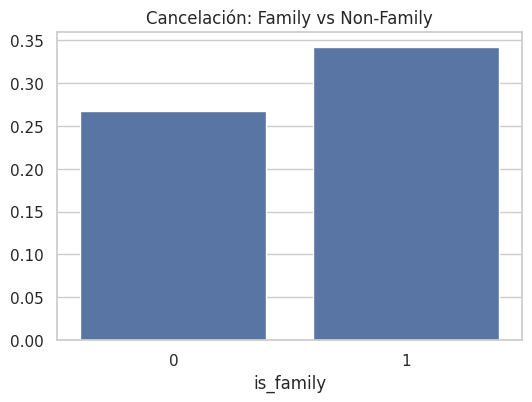

In [96]:
# 17. CANCELACIÓN POR FAMILY BOOKING

family_cancel = data.groupby('is_family')['is_canceled'].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=family_cancel.index, y=family_cancel.values)
plt.title("Cancelación: Family vs Non-Family")
plt.show()

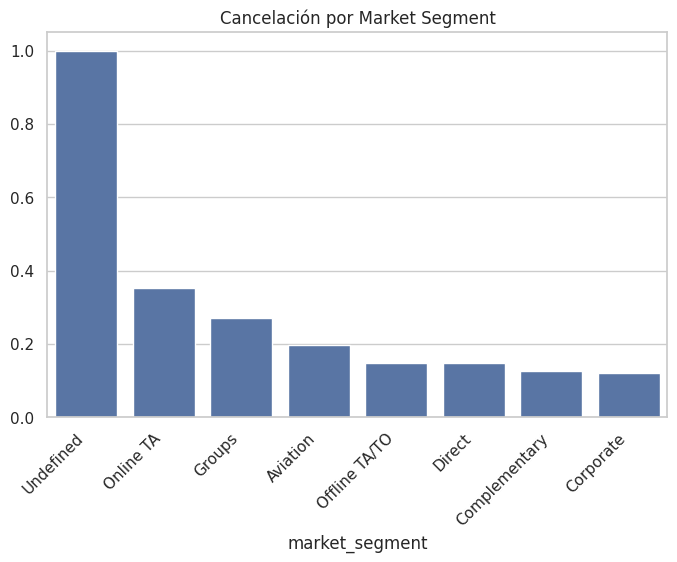

In [97]:

# 18. TOP VARIABLES CATEGÓRICAS
# Explorar market_segment

seg = data.groupby('market_segment')['is_canceled'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=seg.index, y=seg.values)
plt.xticks(rotation=45, ha='right')
plt.title("Cancelación por Market Segment")
plt.show()

In [98]:
# 19. INSIGHTS

print("Promedio cancelación:", round(data['is_canceled'].mean(),3))
print("Lead time promedio cancelados:",
      round(data[data['is_canceled']==1]['lead_time'].mean(),2))
print("Lead time promedio no cancelados:",
      round(data[data['is_canceled']==0]['lead_time'].mean(),2))

Promedio cancelación: 0.275
Lead time promedio cancelados: 105.72
Lead time promedio no cancelados: 70.1


Las reservas que terminan cancelándose fueron hechas, en promedio, con más anticipación que las reservas no canceladas.

Esto sugiere que mientras más tiempo pasa entre la reserva y la fecha de llegada, mayor puede ser la probabilidad de cancelación, posiblemente porque los clientes cambian planes, encuentran mejores opciones o modifican su viaje.

La variable lead_time parece ser un factor importante para predecir cancelaciones, por lo que se espera que tenga peso relevante en los modelos de Machine Learning.

In [99]:
# ==========================================
# BLOQUE 1. DEFINIR X e y
# Objetivo: Preparación para Machine Learning
# ==========================================

# X: variables explicativas (todo excepto is_canceled).
# y: variable objetivo (0=no canceló, 1=canceló).

X = data.drop(columns='is_canceled')
y = data['is_canceled']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (87396, 30)
y shape: (87396,)


In [100]:
# ==========================================
# BLOQUE 2. IDENTIFICAR VARIABLES
# ==========================================

# Separamos columnas en:

# Categóricas: texto/categorías (hotel, meal, etc.).
# Numéricas: cantidades (lead_time, adr, etc.).

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical:", len(cat_cols))
print(cat_cols)

print("Numerical:", len(num_cols))
print(num_cols[:20])

Categorical: 10
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
Numerical: 20
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_guests', 'total_nights', 'is_family']


In [101]:
# ==========================================
# BLOQUE 3. TRAIN TEST SPLIT
# ==========================================

# Reservamos datos para evaluar el modelo con información no vista.

# Train (80%): para aprender patrones.
# Test (20%): para medir rendimiento real.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(69916, 30) (17480, 30)


In [102]:
# ==========================================
# BLOQUE 4. PREPROCESSING PIPELINE
# ==========================================

# Transformaciones automáticas antes del modelo:

# StandardScaler: normaliza variables numéricas.
# OneHotEncoder: convierte categorías en columnas binarias.

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [103]:
# ==========================================
# BLOQUE 5. MODELO BASE
# ==========================================

# En esta sección entrenamos el modelo base: Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_model = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=2000))
])

lr_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellations',
                                                   'previous_bookings_not_canceled',
                                                   'booking_changes',
                                                   'days_in...
                                                   'required_car_parking_spaces',
                                                   'total_of_special_requests',
                                                   'total_guests',
                                                   'total_nights',
                                                   'is_family']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type'])])),
                ('model', LogisticRegression(max_iter=2000))])

prep → prepara los datos antes del modelo:
Escala variables numéricas con StandardScaler
Convierte variables categóricas en formato numérico con OneHotEncoder.

model → aplica LogisticRegression, que calcula la probabilidad de que una reserva sea cancelada.

El modelo de Logistic Regression fue utilizada como modelo base para establecer una referencia inicial. El entrenamiento se completó correctamente y el modelo quedó listo para evaluar su capacidad predictiva sobre nuevas reservas.

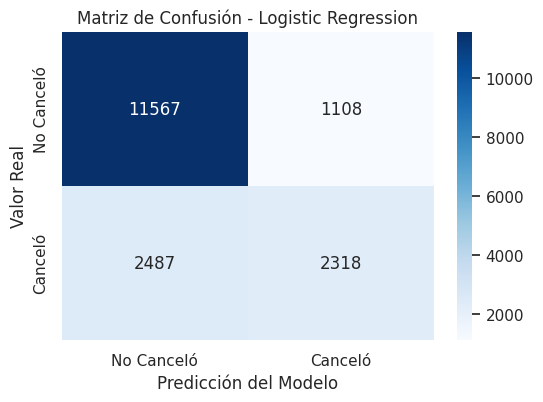

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.91      0.87     12675
           1       0.68      0.48      0.56      4805

    accuracy                           0.79     17480
   macro avg       0.75      0.70      0.71     17480
weighted avg       0.78      0.79      0.78     17480



In [108]:
# ==========================================
# BLOQUE 6. EVALUACIÓN LOGISTIC REGRESSION
# ==========================================

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Predicciones
pred_lr = lr_model.predict(X_test)

# Matriz de confusión numérica
cm = confusion_matrix(y_test, pred_lr)

# Visualización
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Canceló', 'Canceló'],
    yticklabels=['No Canceló', 'Canceló']
)

plt.title("Matriz de Confusión - Logistic Regression")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real")
plt.show()

# Reporte de clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, pred_lr))

El modelo identifica muy bien las reservas normales, pero pierde bastantes cancelaciones reales (2487 casos).

Accuracy = 0.79 (El modelo acierta el 79% de todas las predicciones.)

Precision clase 1 = 0.68 (Cuando el modelo predice cancelación, 68% de las veces tiene razón.)

Recall clase 1 = 0.48 (De todas las reservas que sí fueron canceladas, el modelo solo detecta 48%.)

F1-score clase 1 = 0.56 (Balance moderado entre precisión y recall.)

La Regresión Logística logró una precisión general aceptable (79%), pero su capacidad para detectar cancelaciones reales fue limitada, con un recall de 48%. Esto indica que funciona como modelo base, aunque sería recomendable probar modelos más avanzados para mejorar la detección de reservas canceladas.

In [105]:
# ==========================================
# BLOQUE 7. RANDOM FOREST
# ==========================================

# Es un modelo basado en muchos árboles de decisión trabajando en conjunto.
# En lugar de depender de un solo árbol, crea varios árboles y cada uno emite una
# predicción. Luego el modelo decide por votación mayoritaria.

from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('prep', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=80,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


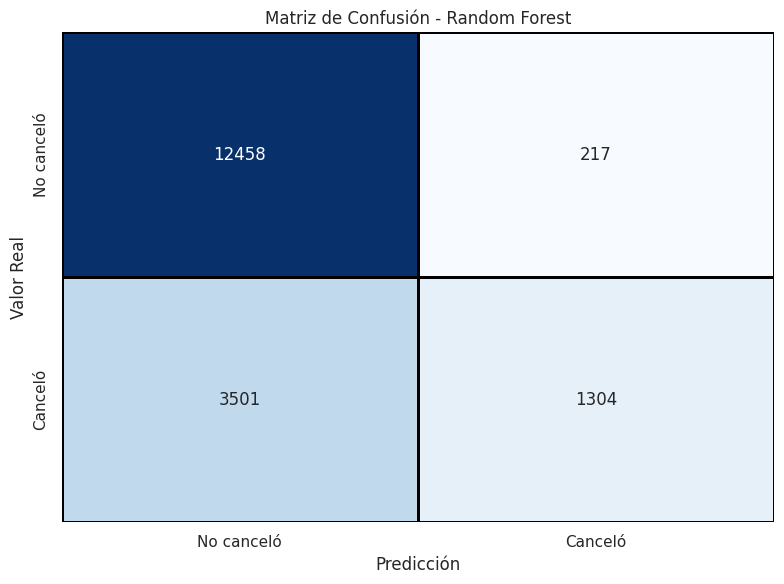

Reporte de Clasificación:

              precision    recall  f1-score   support

           0       0.78      0.98      0.87     12675
           1       0.86      0.27      0.41      4805

    accuracy                           0.79     17480
   macro avg       0.82      0.63      0.64     17480
weighted avg       0.80      0.79      0.74     17480



In [110]:
# ==========================================
# BLOQUE 8. EVALUACIÓN RANDOM FOREST
# ==========================================

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predicciones
pred_rf = rf_model.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, pred_rf)

# Visualización
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    linewidths=1,
    linecolor='black',
    xticklabels=['No canceló', 'Canceló'],
    yticklabels=['No canceló', 'Canceló']
)

plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.tight_layout()
plt.show()

# Reporte de clasificación
print("Reporte de Clasificación:\n")
print(classification_report(y_test, pred_rf))

El modelo identifica muy bien las reservas normales, pero pierde una gran cantidad de cancelaciones reales (3501 casos).

Accuracy = 0.79 (El modelo acierta el 79% de todas las predicciones.)

Precision clase 1 = 0.86 (Cuando el modelo predice cancelación, 86% de las veces tiene razón.)

Recall clase 1 = 0.27 (De todas las reservas que sí fueron canceladas, el modelo solo detecta 27%.)

F1-score clase 1 = 0.41 (Balance bajo entre precisión y recall.)

El modelo Random Forest logró una precisión general aceptable (79%) y una alta precisión al predecir cancelaciones, pero su capacidad para detectar cancelaciones reales fue muy baja, con un recall de solo 27%. Esto indica que el modelo es demasiado conservador al identificar cancelaciones y, en este caso, tuvo un desempeño inferior a la Regresión Logística para el objetivo principal del proyecto.

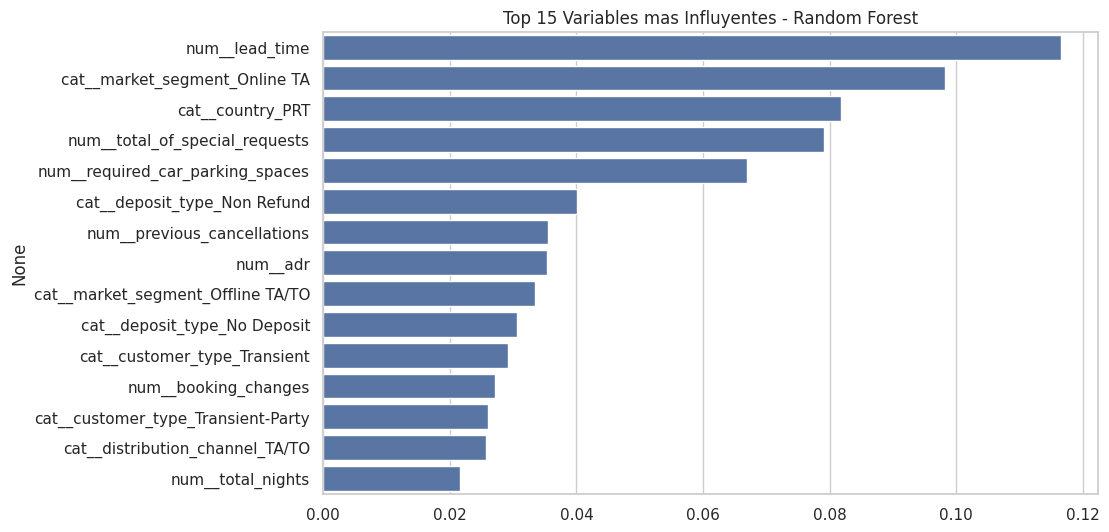

In [111]:
# Extraer modelo interno
rf_final = rf_model.named_steps['model']

# nombres columnas transformadas
feature_names = rf_model.named_steps['prep'].get_feature_names_out()

importances = pd.Series(
    rf_final.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 15 Variables mas Influyentes - Random Forest")
plt.show()

El análisis de importancia de variables mostró que lead_time fue la característica más influyente en la predicción de cancelaciones, indicando que las reservas realizadas con mucha anticipación tienen mayor riesgo de cancelarse.

También destacaron variables como market_segment_Online TA, deposit_type, adr y previous_cancellations, lo que confirma que el canal de reserva, las políticas de pago, el precio y el historial del cliente son factores relevantes.

Estos resultados coinciden con el análisis exploratorio previo y aportan valor de negocio, ya que permiten enfocar estrategias preventivas en reservas de mayor riesgo.